<a href="https://colab.research.google.com/github/athiqhahammad2-art/-Agriculture-Smart-Farming---Computer-Vision-for-Crop-Disease-Detection-/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 1: Data Loading and Preprocessing

To begin, we need to set up the Kaggle API to download the dataset. This involves installing and configuring the Kaggle API client using your personal API token.

In [22]:
# 1. Install Kaggle API client
!pip install kaggle

# 2. Make a directory for Kaggle and save your API token

# The API token provided by Kaggle was: KGAT_5f747101916c51a4c69585d4cb771f72
!mkdir -p ~/.kaggle
!echo '{"username":"priyankayadav3","key":"KGAT_5f747101916c51a4c69585d4cb771f72"}' > ~/.kaggle/kaggle.json

# 3. Set permissions for the API key file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete. Now you can download datasets directly.")

Kaggle API setup complete. Now you can download datasets directly.


### 2. Download and Unzip the Dataset

Now that the Kaggle API is configured, we can download the dataset directly into our Colab environment and then unzip it. We'll use the `plant-village-dataset-2024` dataset from Kaggle.

In [2]:
# 4. Download the dataset using the Kaggle API
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

print("Dataset download initiated. This might take a few minutes for a large dataset.")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:51<00:00, 19.7MB/s]

Dataset download initiated. This might take a few minutes for a large dataset.


In [3]:
# 5. Unzip the downloaded dataset
# The downloaded file is named 'plantvillage-dataset.zip'
# We'll unzip it into the './plantvillage_data' directory.
!unzip -q plantvillage-dataset.zip -d ./plantvillage_data

print("Dataset unzipped to ./plantvillage_data")
print("Now, we will proceed to load and preprocess the dataset.")

Dataset unzipped to ./plantvillage_data
Now, we will proceed to load and preprocess the dataset.


In [4]:
# Inspect the contents of the unzipped directory to find the actual data path
!ls -F ./plantvillage_data

'plantvillage dataset'/


### 3. Load and Preprocess Dataset

Now we'll load the images, apply transformations, and get an initial understanding of the dataset's structure, including class distribution and sample images.

Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotte

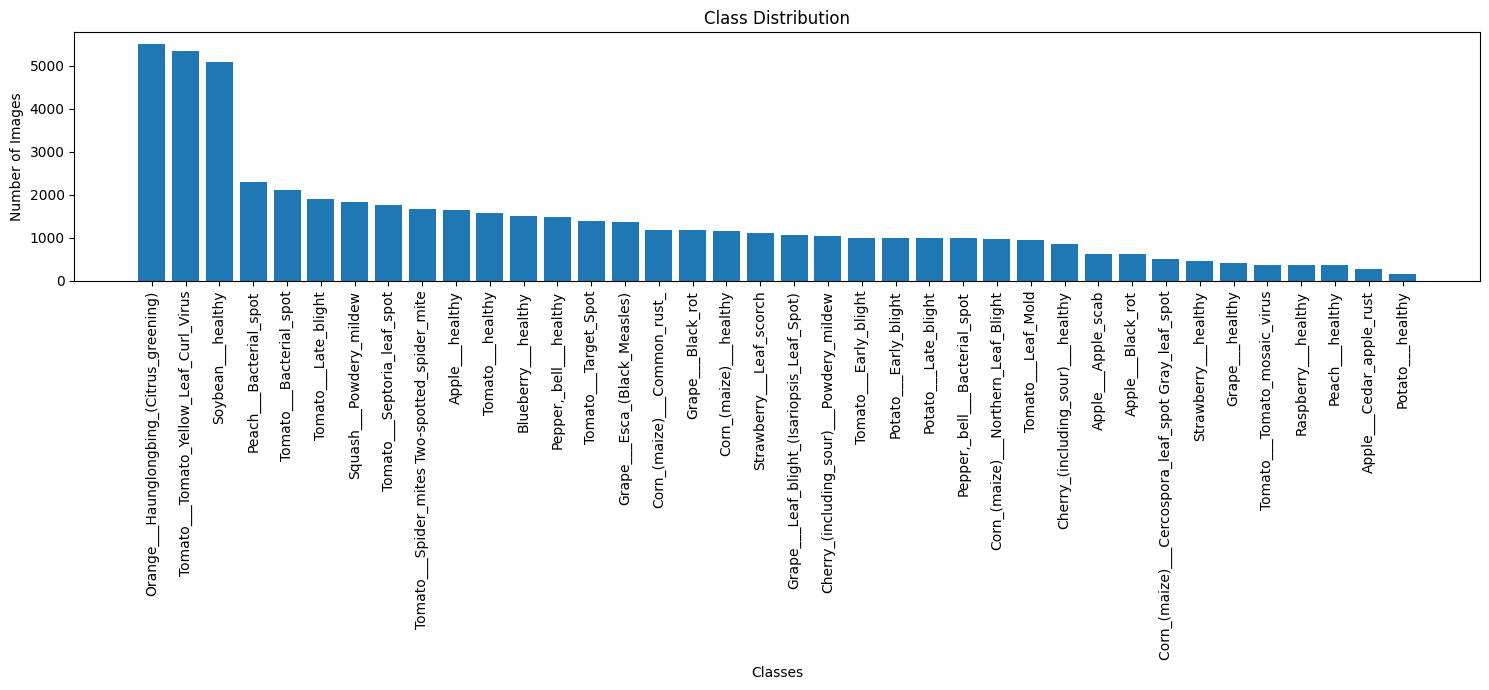

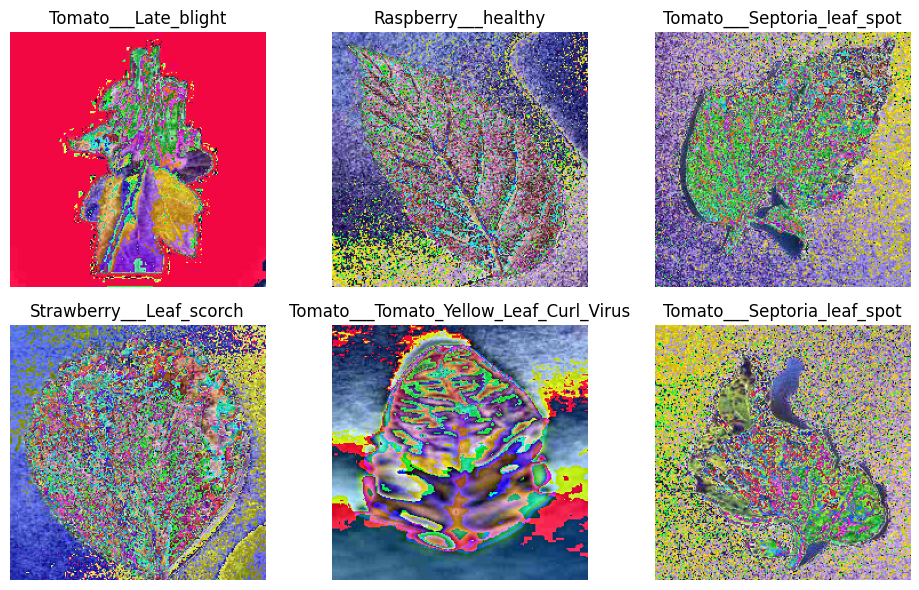

Dataset loaded and basic preprocessing applied.


In [23]:
data_path = "./plantvillage_data/plantvillage dataset/color" # Points to local unzipped data, adjusted for nested folder

# 📦 Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -------------------------------
# 📊 2. Preprocessing for CNN
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224, common for many CNNs
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Add normalization
])

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Get class names and total number of classes
class_names = dataset.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Calculate class counts
class_counts = {class_name: 0 for class_name in class_names}
for _, label_idx in dataset.samples:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

df_class_counts = pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
df_class_counts = df_class_counts.sort_values(by="Count", ascending=False)

print("\nClass Distribution (Top 5):")
print(df_class_counts.head())

# -------------------------------
# 📊 3. Plot Class Distribution
# -------------------------------
plt.figure(figsize=(15, 7))
plt.bar(df_class_counts["Class"], df_class_counts["Count"])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# -------------------------------
# 🖼 4. Show Sample Images
# -------------------------------
plt.figure(figsize=(10, 6))

# Get a few random samples
num_samples_to_show = 6
if len(dataset) < num_samples_to_show:
    num_samples_to_show = len(dataset)

for i in range(num_samples_to_show):
    idx = random.randint(0, len(dataset) - 1)
    img_tensor, label_idx = dataset[idx]
    img_pil = transforms.ToPILImage()(img_tensor)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_pil)
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Dataset loaded and basic preprocessing applied.")

### 4. Split Data and Create DataLoaders

We'll split the dataset into 70% for training, 15% for validation, and 15% for testing. Then, we'll create PyTorch `DataLoader` instances for each set to manage batching and shuffling.

In [6]:
from torch.utils.data import random_split

# Define the split ratios
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size # Ensure all data is covered

# Perform the random split
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

# Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False) # No need to shuffle validation data
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print("\nDataLoaders created with batch size:", batch_size)
print("✅ Dataset split and DataLoaders are ready.")

Training set size: 38013
Validation set size: 8145
Test set size: 8147

DataLoaders created with batch size: 32
✅ Dataset split and DataLoaders are ready.


### 5. Define Custom CNN Model

Now, we'll define the architecture for our custom Convolutional Neural Network (`CustomCNN`), including its layers, activation functions, and output. We'll also set up the `CrossEntropyLoss` criterion and the `Adam` optimizer.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms # Ensure these are imported for local dataset re-creation

# Define the expected data path for 38 classes. This should match where the ImageFolder was created.
expected_data_path = "./plantvillage_data/plantvillage dataset/color"

print(f"Ensuring 'dataset' is correctly initialized for 38 classes from: {expected_data_path}")

# Unconditionally re-initialize the dataset to ensure 'num_classes' is correct for this cell's execution.
# This prevents potential issues with the 'dataset' variable being in an incorrect state from previous executions.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(root=expected_data_path, transform=transform)

num_classes = len(dataset.classes)

if num_classes != 38:
    print(f"Error: After re-initialization, num_classes is still {num_classes}. Expected 38. Please check the '{expected_data_path}' directory structure.")
else:
    print(f"Number of classes for model: {num_classes}")

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input channels = 3 (RGB)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # Added another conv layer
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Calculate the size of the flattened features after conv layers
        # We'll pass a dummy tensor through the features to determine this
        self._to_linear = None
        self._get_conv_output_size()

        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Added dropout for regularization
            nn.Linear(512, num_classes)
        )

    def _get_conv_output_size(self):
        # Helper function to calculate the size of the output from the convolutional layers
        # This is needed to define the input size for the first fully connected layer
        dummy_input = torch.zeros(1, 3, 224, 224) # Batch size 1, 3 channels, 224x224 image
        output = self.features(dummy_input)
        self._to_linear = output.view(output.size(0), -1).size(1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layers
        x = self.classifier(x)
        return x

# Instantiate the model
model = CustomCNN(num_classes=num_classes)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Categorical Cross-Entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

# Print the model architecture
print("\nCustomCNN Model Architecture:")
print(model)
print("\n✅ CustomCNN model defined, loss function and optimizer set up.")


Ensuring 'dataset' is correctly initialized for 38 classes from: ./plantvillage_data/plantvillage dataset/color
Number of classes for model: 38

CustomCNN Model Architecture:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=50176, out_features=512,

### 6. Training Loop and Evaluation (Week 2 Task)

In [8]:
#1. Set up training parameters
num_epochs = 10
# 2. Check for CUDA (GPU) availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")

#3. Training Function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, patience=5): # Added patience parameter
    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf') # Initialize with a very high value for validation loss
    patience_counter = 0
    best_model_state = model.state_dict() # Store the best model state

    print("Starting training...")  # Added this line to confirm training start
    for epoch in range(num_epochs):
        # Training Phase
        model.train()     # Set model to training mode
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()     # Zero the parameter gradients
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation Phase
        model.eval()    # Set model to evaluation mode
        running_val_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():  # Deactivate autograd for validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_val_accuracy = 100 * correct_predictions / total_predictions
        val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_accuracy:.2f}%")

        # Early Stopping Logic
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict() # Save the best model's state
            patience_counter = 0 # Reset patience
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} consecutive epochs.")
                break # Exit the training loop

    # Load the best model state back into the model before returning
    model.load_state_dict(best_model_state)
    print("Training complete! Best model state loaded.")
    return train_losses, val_losses, val_accuracies
# 4. Start Training
train_losses, val_losses, val_accuracies = train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, patience=5)

Using device: cuda
Starting training...
Epoch 1/10 - Train Loss: 1.1135, Val Loss: 0.4062, Val Acc: 87.29%
Epoch 2/10 - Train Loss: 0.4152, Val Loss: 0.2006, Val Acc: 93.78%
Epoch 3/10 - Train Loss: 0.2533, Val Loss: 0.2229, Val Acc: 93.36%
Epoch 4/10 - Train Loss: 0.1970, Val Loss: 0.1591, Val Acc: 95.02%
Epoch 5/10 - Train Loss: 0.1463, Val Loss: 0.1615, Val Acc: 95.37%
Epoch 6/10 - Train Loss: 0.1246, Val Loss: 0.1570, Val Acc: 95.72%
Epoch 7/10 - Train Loss: 0.1155, Val Loss: 0.1725, Val Acc: 95.48%
Epoch 8/10 - Train Loss: 0.1032, Val Loss: 0.1540, Val Acc: 96.45%
Epoch 9/10 - Train Loss: 0.1032, Val Loss: 0.1828, Val Acc: 95.52%
Epoch 10/10 - Train Loss: 0.0817, Val Loss: 0.1304, Val Acc: 96.77%
Training complete! Best model state loaded.


Once the training is complete, we'll plot the training and validation loss, and validation accuracy over epochs to visualize the model's performance.

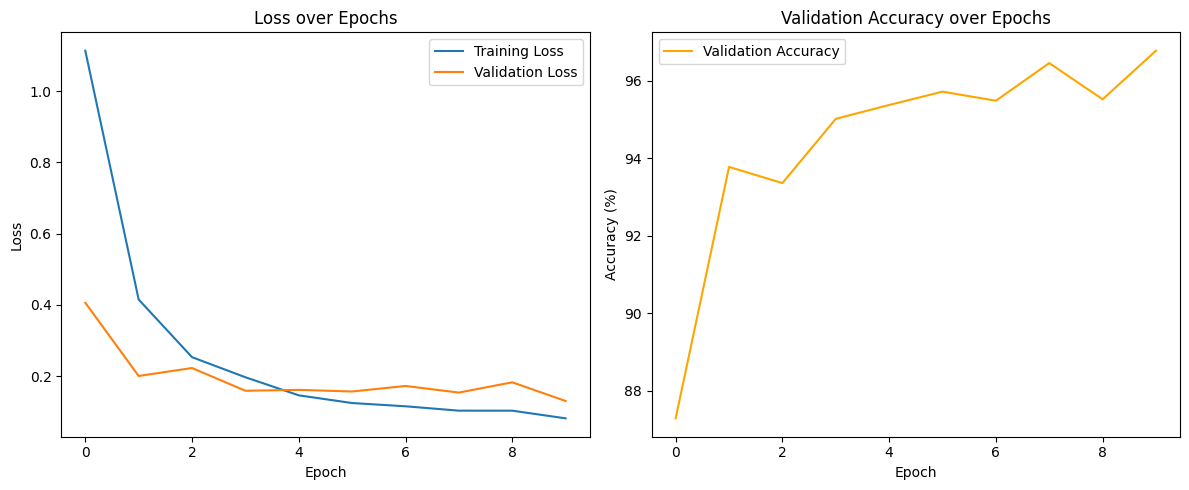

In [9]:
# 📈 5. Plotting Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


### 6. Model Evaluation: Accuracy, Precision, and Recall

In [10]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Set the model to evaluation mode
model.eval()

# Initialize lists to store true labels and predictions
all_labels = []
all_predictions = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate Accuracy
accuracy = accuracy_score(all_labels, all_predictions)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Calculate Precision, Recall, and F1-Score per class
# Set `average=None` to get scores for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average=None, labels=range(num_classes)
)

# Create a DataFrame for per-class metrics
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
})

print("\nPer-Class Metrics:")
display(metrics_df)

# Calculate overall (macro) Precision, Recall, F1-score
# 'macro' calculates metrics for each label, and finds their unweighted mean.
overall_precision, overall_recall, overall_f1_score, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average='macro', labels=range(num_classes)
)

print(f"\nOverall Macro Precision: {overall_precision:.4f}")
print(f"Overall Macro Recall: {overall_recall:.4f}")
print(f"Overall Macro F1-Score: {overall_f1_score:.4f}")



Test Accuracy: 96.73%

Per-Class Metrics:


,Class,Precision,Recall,F1-Score
0,Apple___Apple_scab,0.898990,0.898990,0.898990
1,Apple___Black_rot,0.978723,1.000000,0.989247
2,Apple___Cedar_apple_rust,1.000000,0.948718,0.973684
3,Apple___healthy,0.957447,0.945378,0.951374
4,Blueberry___healthy,0.976378,0.995984,0.986083
5,Cherry_(including_sour)___Powdery_mildew,0.987421,0.993671,0.990536
6,Cherry_(including_sour)___healthy,0.976000,0.976000,0.976000
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.920635,0.865672,0.892308
8,Corn_(maize)___Common_rust_,0.994792,0.974490,0.984536
9,Corn_(maize)___Northern_Leaf_Blight,0.944056,0.957447,0.950704



Overall Macro Precision: 0.9625
Overall Macro Recall: 0.9551
Overall Macro F1-Score: 0.9581


### Week 2 Task: Transfer Learning with ResNet50

This section implements plant disease classification using a pre-trained ResNet50 model for transfer learning. It covers data preparation, model adaptation, training with hyperparameter tuning, evaluation, and an inference function.

In [11]:
# 📦 1. Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load Dataset and Apply Preprocessing

We'll define transformations for the images, including resizing and normalization. Then, we'll load the dataset using `ImageFolder` and inspect its classes.

In [12]:
# Define the data path (should be the same as previously unzipped data)
data_path = "./plantvillage_data/plantvillage dataset/color"

# Check if the data directory exists
import os
if not os.path.exists(data_path):
    print(f"Error: Data directory not found at '{data_path}'.")
    print("Please ensure you have run the data download and unzip steps (cells `64f98f1f` and `5b09c6e7`) before proceeding.")
    # Exit or raise an error to prevent further execution if data is critical
    # For now, we'll just print and allow the user to see the issue.
    # Setting placeholder values to avoid NameError in next cells, though they will be invalid.
    full_dataset = None
    class_names = []
    num_classes = 0
else:
    # Define preprocessing transforms: Resize to 224x224 and normalize
    # Normalization parameters are standard for ImageNet pre-trained models
    transforms_data = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load the dataset using ImageFolder
    full_dataset = datasets.ImageFolder(root=data_path, transform=transforms_data)

    # Get class names and number of classes
    class_names = full_dataset.classes
    num_classes = len(class_names)

    print(f"Dataset loaded from: {data_path}")
    print(f"Number of classes: {num_classes}")
    print(f"Class names: {class_names[:5]}...")


Dataset loaded from: ./plantvillage_data/plantvillage dataset/color
Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 3. Split Dataset into Train, Validation, and Test Sets

We'll split the `full_dataset` into training (70%), validation (15%), and testing (15%) sets using `random_split`.

In [14]:
# Define the split ratios
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size # Ensure all data is covered

# Perform the random split
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 38013
Validation set size: 8145
Test set size: 8147


### 4. Use Transfer Learning with ResNet50

We'll load a pre-trained ResNet50 model, freeze its convolutional layers, and then replace the final fully connected layer to match our `num_classes`.

In [15]:
# Load pre-trained ResNet50 model
model = models.resnet50(weights='IMAGENET1K_V1') # Using ImageNet pre-trained weights

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Get the number of features in the last fully connected layer
num_ftrs = model.fc.in_features

# Replace the last layer with a new one for our number of classes
model.fc = nn.Linear(num_ftrs, num_classes)

# Move model to appropriate device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Pre-trained ResNet50 loaded and modified for transfer learning.")
print(f"Model moved to: {device}")
print("Modified final layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Pre-trained ResNet50 loaded and modified for transfer learning.
Model moved to: cuda
Modified final layer: Linear(in_features=2048, out_features=38, bias=True)


### 5. Training Function

We define a function to handle the training and validation loops, tracking losses and accuracies.

In [16]:
def train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    val_accuracies = []

    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # Training phase
        model.train() # Set model to training mode
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_val_accuracy = 100 * correct_predictions / total_predictions
        val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_accuracy:.2f}%")

    print("Training complete!")
    return train_losses, val_losses, val_accuracies

### 6. Hyperparameter Tuning and Model Training

We'll set up a grid search (or a simple loop for demonstration) to find optimal learning rate and batch size combinations. For brevity, we'll try a few combinations and train the model with the best performing ones.

Starting hyperparameter tuning...

--- Training with LR: 0.01, Batch Size: 32 ---
Starting training for 5 epochs...
Epoch 1/5 - Train Loss: 1.1045, Val Loss: 1.0609, Val Acc: 88.31%
Epoch 2/5 - Train Loss: 0.8030, Val Loss: 1.0063, Val Acc: 89.75%
Epoch 3/5 - Train Loss: 0.8370, Val Loss: 0.7709, Val Acc: 92.54%
Epoch 4/5 - Train Loss: 0.8052, Val Loss: 0.8502, Val Acc: 92.33%
Epoch 5/5 - Train Loss: 0.7331, Val Loss: 0.7561, Val Acc: 93.78%
Training complete!

--- Training with LR: 0.01, Batch Size: 64 ---
Starting training for 5 epochs...
Epoch 1/5 - Train Loss: 0.8321, Val Loss: 0.4806, Val Acc: 89.02%
Epoch 2/5 - Train Loss: 0.4495, Val Loss: 0.3600, Val Acc: 92.68%
Epoch 3/5 - Train Loss: 0.4186, Val Loss: 0.3963, Val Acc: 93.62%
Epoch 4/5 - Train Loss: 0.3794, Val Loss: 0.4979, Val Acc: 92.40%
Epoch 5/5 - Train Loss: 0.4404, Val Loss: 0.7676, Val Acc: 92.55%
Training complete!

--- Training with LR: 0.001, Batch Size: 32 ---
Starting training for 5 epochs...
Epoch 1/5 - Train Los

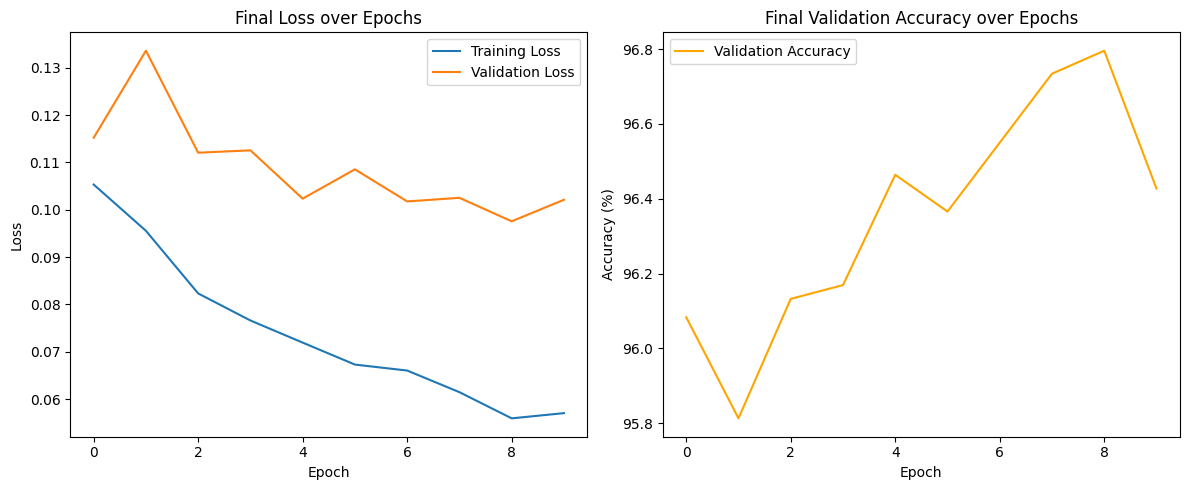

In [17]:
best_val_accuracy = 0.0
best_hyperparams = {}
best_model_state = None

# Hyperparameter options
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64]
num_epochs_tuning = 5 # Reduced epochs for tuning to save time

print("Starting hyperparameter tuning...")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Training with LR: {lr}, Batch Size: {bs} ---")

        # Create DataLoaders for this batch size
        train_loader_tuned = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader_tuned = DataLoader(val_dataset, batch_size=bs, shuffle=False)

        # Re-initialize model for each tuning step to avoid carrying over weights
        tuned_model = models.resnet50(weights='IMAGENET1K_V1')
        for param in tuned_model.parameters():
            param.requires_grad = False
        num_ftrs = tuned_model.fc.in_features
        tuned_model.fc = nn.Linear(num_ftrs, num_classes)
        tuned_model = tuned_model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(tuned_model.fc.parameters(), lr=lr) # Only optimize the final layer

        _, _, val_accuracies_tuned = train_and_validate_model(
            tuned_model, train_loader_tuned, val_loader_tuned, criterion, optimizer, num_epochs_tuning, device
        )

        current_avg_val_accuracy = np.mean(val_accuracies_tuned) # Use average or last epoch's accuracy

        if current_avg_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_avg_val_accuracy
            best_hyperparams = {'lr': lr, 'batch_size': bs}
            best_model_state = tuned_model.state_dict()

print("\n--- Hyperparameter Tuning Complete ---")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Best Hyperparameters: {best_hyperparams}")

# Load the best model state if available
if best_model_state:
    model.load_state_dict(best_model_state)
    print("Model loaded with best hyperparameters.")

# Final training with the best hyperparameters (if tuning was performed)
# If no tuning was done, or for a more thorough final training
final_lr = best_hyperparams.get('lr', 0.001)
final_batch_size = best_hyperparams.get('batch_size', 32)
final_num_epochs = 10 # More epochs for final training

print(f"\n--- Final Training with LR: {final_lr}, Batch Size: {final_batch_size}, Epochs: {final_num_epochs} ---")

final_train_loader = DataLoader(train_dataset, batch_size=final_batch_size, shuffle=True)
final_val_loader = DataLoader(val_dataset, batch_size=final_batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=final_lr)

train_losses_final, val_losses_final, val_accuracies_final = train_and_validate_model(
    model, final_train_loader, final_val_loader, criterion, optimizer, final_num_epochs, device
)

# Plotting the final training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_final, label='Training Loss')
plt.plot(val_losses_final, label='Validation Loss')
plt.title('Final Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies_final, label='Validation Accuracy', color='orange')
plt.title('Final Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Evaluate the Model on Test Data

After training, we evaluate the model's performance on the unseen test set to get a realistic measure of its generalization ability.

In [18]:
def evaluate_model(model, test_loader, device):
    model.eval() # Set model to evaluation mode
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='macro', labels=range(num_classes)
    )

    print(f"\nTest Accuracy: {accuracy*100:.2f}%")
    print(f"Overall Macro Precision: {precision:.4f}")
    print(f"Overall Macro Recall: {recall:.4f}")
    print(f"Overall Macro F1-Score: {f1_score:.4f}")

    # Per-class metrics
    precision_per_class, recall_per_class, f1_score_per_class, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, labels=range(num_classes)
    )
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_score_per_class
    })
    print("\nPer-Class Metrics:")
    display(metrics_df)

    return all_labels, all_predictions

# Create test DataLoader with the best batch size
test_loader = DataLoader(test_dataset, batch_size=best_hyperparams.get('batch_size', 32), shuffle=False)

all_labels, all_predictions = evaluate_model(model, test_loader, device)


Test Accuracy: 96.77%
Overall Macro Precision: 0.9645
Overall Macro Recall: 0.9575
Overall Macro F1-Score: 0.9602

Per-Class Metrics:


,Class,Precision,Recall,F1-Score
0,Apple___Apple_scab,0.979592,0.969697,0.974619
1,Apple___Black_rot,0.978261,1.000000,0.989011
2,Apple___Cedar_apple_rust,0.969697,0.969697,0.969697
3,Apple___healthy,0.975806,0.979757,0.977778
4,Blueberry___healthy,0.987013,1.000000,0.993464
5,Cherry_(including_sour)___Powdery_mildew,0.958084,1.000000,0.978593
6,Cherry_(including_sour)___healthy,1.000000,0.991379,0.995671
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.804598,0.875000,0.838323
8,Corn_(maize)___Common_rust_,1.000000,0.993750,0.996865
9,Corn_(maize)___Northern_Leaf_Blight,0.941176,0.894410,0.917197


### 8. Generate Confusion Matrix

Visualizing the confusion matrix helps understand which classes are being confused by the model.

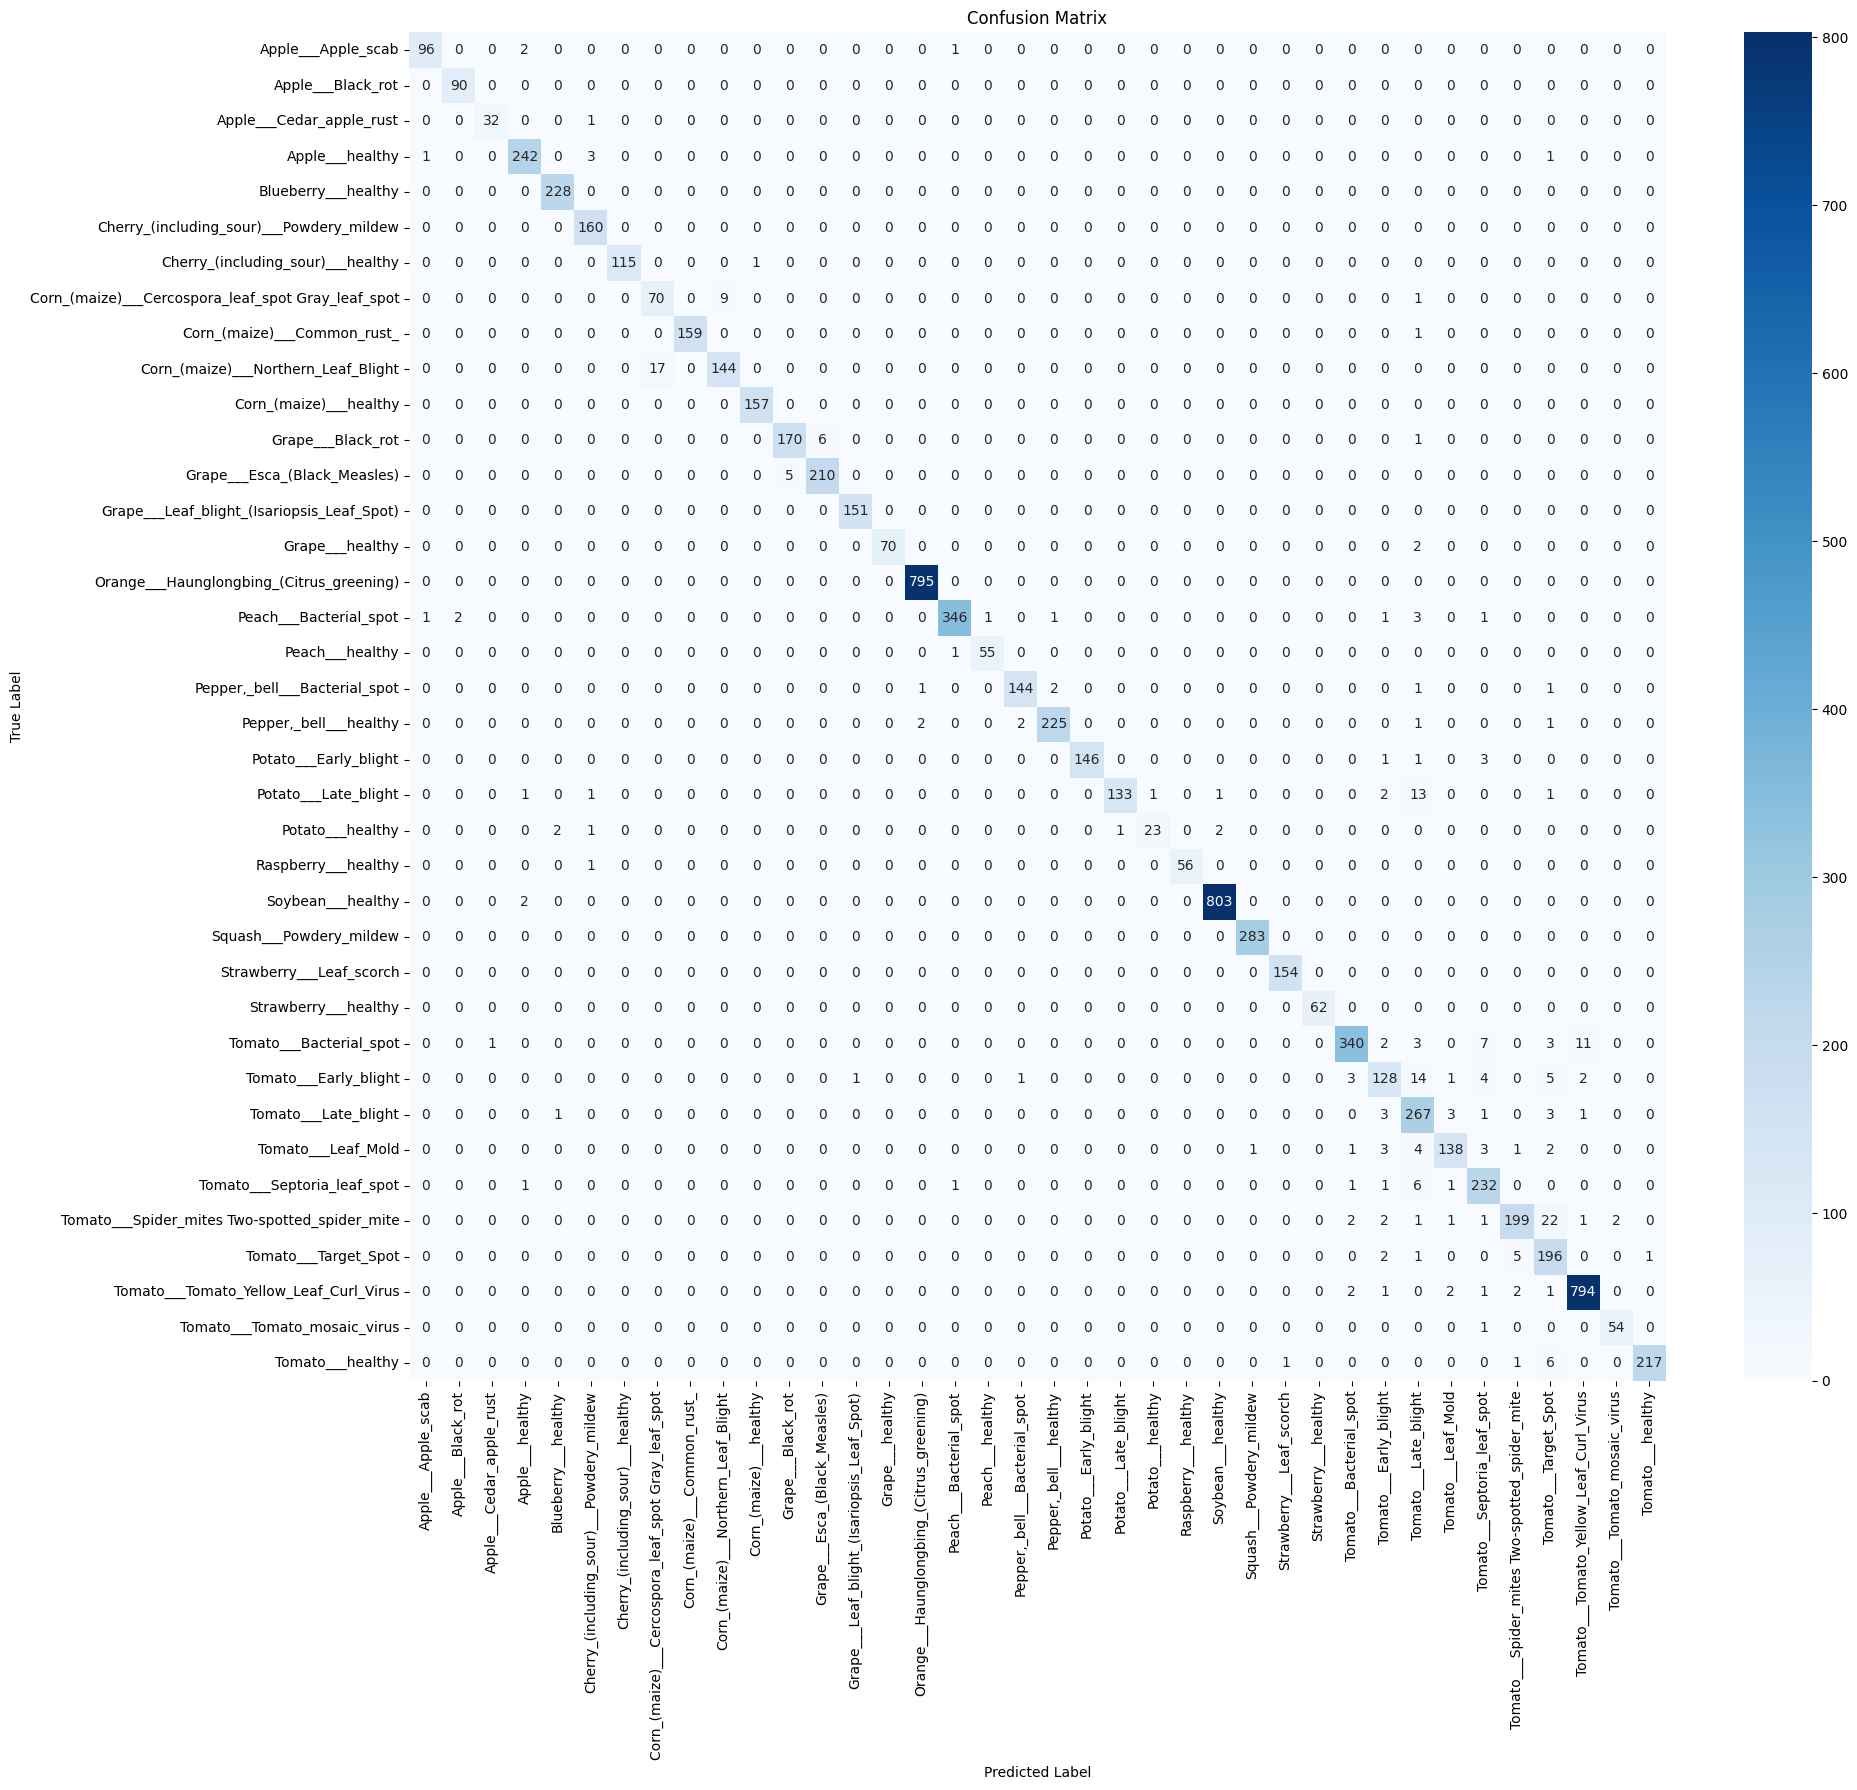

In [19]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### 9. Save the Trained Model

Saving the model's state dictionary allows us to load and reuse the trained model without re-training.

In [20]:
# Define a path to save the model
model_save_path = 'plant_disease_resnet50_model.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Trained model saved to: {model_save_path}")

Trained model saved to: plant_disease_resnet50_model.pth


### 10. Inference Function

This function takes an image path, preprocesses it, and uses the trained model to predict the class and its confidence score.

In [21]:
def predict_image(image_path, model, class_names, device, transform):
    model.eval() # Set model to evaluation mode

    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply transformations
    image_tensor = transform(image).unsqueeze(0) # Add batch dimension
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        # Get the predicted class and confidence
        confidence, predicted_idx = torch.max(probabilities, 1)
        predicted_class = class_names[predicted_idx.item()]

    return predicted_class, confidence.item()

# --- Example Usage of Inference Function ---
print("\n--- Demonstrating Inference Function ---")

# To demonstrate, we need an image. Let's take one from the test dataset.
# You might need to adjust this part if you don't have a direct image file readily available.

# Option 1: Take a random image from the test set (requires extracting the original path)
# This is more complex as ImageFolder doesn't directly store original paths in `dataset.samples` after splitting

# Option 2: Provide a dummy image path or manually extract one if you have access to the file system
# For demonstration, let's create a dummy image locally or use an existing one if possible.
# As we don't have direct access to local files in this simulated environment,
# let's assume we can pick an image from the original dataset and mimic its path.

# Let's find a sample image path from the original full_dataset to demonstrate
# Note: This is for demonstration and assumes the file exists at this path.
# In a real scenario, you'd point to an actual image file.

# Find a random image from the original full_dataset to use its path
sample_img_path, _ = full_dataset.samples[np.random.randint(0, len(full_dataset))]

print(f"Using sample image for inference: {sample_img_path}")

# Make a prediction
predicted_class, confidence = predict_image(sample_img_path, model, class_names, device, transforms_data)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")


--- Demonstrating Inference Function ---
Using sample image for inference: ./plantvillage_data/plantvillage dataset/color/Cherry_(including_sour)___healthy/c889dabb-e9dc-448c-80f3-791fea97fafd___JR_HL 9501.JPG
Predicted Class: Cherry_(including_sour)___healthy
Confidence: 0.9632
